# Data Visualization
1. now we will do geospation analysis based on the neighborhood data
2. join with our citibike data,
3. visualize top routes
   
    A. change width

    B.change color
    
4. Choropleth Maps

## Loading Libraries

In [ ]:
import pandas as pd

import folium

import geopandas as gpd

## Read and Visualize `jersey-city-neighborhoods.geojson` data

In [2]:
geojson_url = 'https://raw.githubusercontent.com/hovhannisyan91/aca/refs/heads/main/lab/python/data/citibike/JC/jersey-city-neighborhoods.geojson'
OUTPUT_DIR = "../data/JC/"

In [3]:
gdf = gpd.read_file(geojson_url)
gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


### Data enrichment

#### Add a column for area by square km

In [9]:
gdf["area_sq_km"] = gdf["area_sq_ft"] * 0.00000009290304

gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,geometry,area_sq_km
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",38.23902
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",38.23902
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",38.23902
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",38.23902
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",38.23902


#### Add columns for Population Count and Population Density by District

In [11]:
TOTAL_POPULATION = 304205

total_sq_km = gdf["area_sq_km"].sum()

# nbhd_population
gdf["nbhd_population"] = (gdf["area_sq_km"] / total_sq_km) * TOTAL_POPULATION

# 4. Calculate Density per Square Kilometer
gdf["population_density_per_sq_km"] = gdf["nbhd_population"] / gdf["area_sq_km"]

# 5. Review the updated structure
print(gdf[["neighborhood", "area_sq_km", "nbhd_population", "population_density_per_sq_km"]].head())


     neighborhood  area_sq_km  nbhd_population  population_density_per_sq_km
0    Port Liberte    38.23902      5739.716981                     150.10105
1  LSP Industrial    38.23902      5739.716981                     150.10105
2      Hackensack    38.23902      5739.716981                     150.10105
3       Lafayette    38.23902      5739.716981                     150.10105
4    Jackson Hill    38.23902      5739.716981                     150.10105


### Store geodata

In [12]:
url = f'{OUTPUT_DIR}/jersey-city-neighborhoods.geojson'
gdf.to_file(url, driver="GeoJSON")

### Read geodata from the folder and inspect

In [13]:
url = f'{OUTPUT_DIR}/jersey-city-neighborhoods.geojson'

jersey_city = gpd.read_file(url)

jersey_city.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,area_sq_km,estimated_neighborhood_population,population_density_per_sq_km,nbhd_population,geometry
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.06862 40.70098, -74.06808 40.696..."
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.06808 40.69684, -74.06862 40.700..."
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.07601 40.73822, -74.07781 40.737..."
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ..."
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020..."


In [14]:
jersey_city.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   cartodb_id                         53 non-null     int32   
 1   area_sq_ft                         53 non-null     float64 
 2   acres                              53 non-null     float64 
 3   area                               53 non-null     str     
 4   neighborhood                       53 non-null     str     
 5   color                              18 non-null     float64 
 6   lon                                53 non-null     float64 
 7   lat                                53 non-null     float64 
 8   area_sq_km                         53 non-null     float64 
 9   estimated_neighborhood_population  53 non-null     float64 
 10  population_density_per_sq_km       53 non-null     float64 
 11  nbhd_population                    53 n

In [15]:
jersey_city.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [16]:
jersey_city = jersey_city.to_crs("EPSG:4326")


<Axes: >

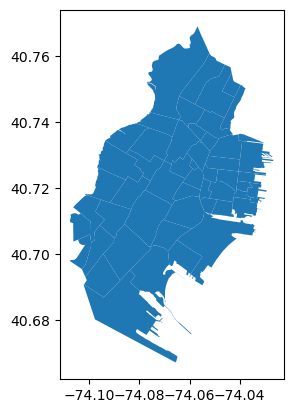

In [17]:
jersey_city.plot()

### Read Rides Data

In [18]:
citybike_df = pd.read_csv(f"{OUTPUT_DIR}/JC2025_Enriched.csv")
citybike_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_duration_minutes,date,month,month_name,day_of_week,hour,season
0,9F734BE1BFC45FF4,electric_bike,2025-11-18 18:34:14.943,2025-11-18 18:47:33.391,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,13.307467,2025-11-18,2025-11,November,Tuesday,18,Autumn
1,B6C773B13AC0E465,classic_bike,2025-11-26 16:29:15.513,2025-11-26 16:43:45.235,Glenwood Ave,JC094,West Side Ave & Stegman Pkwy,JC131,40.727551,-74.071061,40.710870,-74.093680,member,14.495367,2025-11-26,2025-11,November,Wednesday,16,Autumn
2,C300465AA158280F,electric_bike,2025-11-04 22:31:58.010,2025-11-04 22:38:57.017,Bloomfield St & 15 St,HB203,Marshall St & 2 St,HB408,40.754530,-74.026580,40.740802,-74.042521,member,6.983450,2025-11-04,2025-11,November,Tuesday,22,Autumn
3,31A424FC97C8AAFB,classic_bike,2025-11-08 06:51:57.424,2025-11-08 06:57:45.627,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,5.803383,2025-11-08,2025-11,November,Saturday,6,Autumn
4,08C5EA04CB1FDC57,classic_bike,2025-11-24 20:31:21.758,2025-11-24 20:38:01.261,Clinton St & 7 St,HB303,Marshall St & 2 St,HB408,40.745420,-74.033320,40.740802,-74.042521,member,6.658383,2025-11-24,2025-11,November,Monday,20,Autumn


### Station Level SummaryPrepare Data for station level analysis
1. moving from trip level analysis into station level analysis
2. departures
3. arrivals
4. concat departures and arrivals
5. create derived columns
   
    A. total_arrivals

    B. total_departues

    C.total_activity

    D. net_departures

#### Start stations

In [19]:
start_stations = citybike_df[
    [
        "ride_id",
        "start_station_id",
        "start_station_name",
        "start_lat",
        "start_lng"
    ]
].copy()

start_stations = start_stations.rename(
    columns={
        "start_station_id": "station_id",
        "start_station_name": "station_name",
        "start_lat": "lat",
        "start_lng": "lng"
    }
)

start_stations["activity_type"] = "departure"

#### End stations

In [20]:
end_stations = citybike_df[
    [
        "ride_id",
        "end_station_id",
        "end_station_name",
        "end_lat",
        "end_lng"
    ]
].copy()

end_stations = end_stations.rename(
    columns={
        "end_station_id": "station_id",
        "end_station_name": "station_name",
        "end_lat": "lat",
        "end_lng": "lng"
    }
)

end_stations["activity_type"] = "arrival"

end_stations.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
1,B6C773B13AC0E465,JC131,West Side Ave & Stegman Pkwy,40.710870,-74.093680,arrival
2,C300465AA158280F,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
3,31A424FC97C8AAFB,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival
4,08C5EA04CB1FDC57,HB408,Marshall St & 2 St,40.740802,-74.042521,arrival


#### Concatenate Departures and Arrivals

In [21]:
station_activity_long = pd.concat(
    [
        start_stations,
        end_stations
    ],
    ignore_index=True
)

station_activity_long = station_activity_long.dropna(
    subset=[
        "station_id",
        "station_name",
        "lat",
        "lng"
    ]
)

station_activity_long.head()

,ride_id,station_id,station_name,lat,lng,activity_type
0,9F734BE1BFC45FF4,JC094,Glenwood Ave,40.727551,-74.071061,departure
1,B6C773B13AC0E465,JC094,Glenwood Ave,40.727551,-74.071061,departure
2,C300465AA158280F,HB203,Bloomfield St & 15 St,40.754530,-74.026580,departure
3,31A424FC97C8AAFB,HB303,Clinton St & 7 St,40.745420,-74.033320,departure
4,08C5EA04CB1FDC57,HB303,Clinton St & 7 St,40.745420,-74.033320,departure


#### Cleaning and Aggregating

In [22]:
station_activity_agg = (
    station_activity_long
    .groupby(
        [
            "station_id",
            "station_name",
            "lat",
            "lng",
            "activity_type"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
)

station_activity_agg.tail()

,station_id,station_name,lat,lng,activity_type,number_of_rides
595,JC143,MLK Dr & Bayview Ave,40.70710,-74.08335,departure,6
596,JC144,Danforth Ave & JFK Blvd,40.70056,-74.09474,arrival,7
597,JC144,Danforth Ave & JFK Blvd,40.70056,-74.09474,departure,6
598,JC145,Mallory Ave & Roosevelt Ave,40.72203,-74.08596,arrival,28
599,JC145,Mallory Ave & Roosevelt Ave,40.72203,-74.08596,departure,24


#### Pivot the Data
##### Pivot to One Row per Station

In [23]:
station_summary = (
    station_activity_agg
    .pivot_table(
        index=[
            "station_id",
            "station_name",
            "lat",
            "lng"
        ],
        columns="activity_type",
        values="number_of_rides",
        fill_value=0
    )
    .reset_index()
)

station_summary.head()

activity_type,station_id,station_name,lat,lng,arrival,departure
0,3278.07,Brooklyn Ave & Snyder Ave,40.649150,-73.943680,1.0,0.0
1,3344.02,Park Circle & East Dr,40.651566,-73.972212,1.0,0.0
2,3480.04,Parkside Ave & Flatbush Ave,40.655630,-73.959680,1.0,0.0
3,3579.04,Windsor Pl & Howard Pl,40.659491,-73.980139,1.0,0.0
4,3762.08,10 St & 7 Ave,40.666208,-73.981999,1.0,0.0


##### Rename and Create Final Metrics

In [24]:
station_summary = station_summary.rename(
    columns={
        "departure": "total_departures",
        "arrival": "total_arrivals"
    }
)

station_summary["total_activity"] = (
    station_summary["total_departures"] +
    station_summary["total_arrivals"]
)

station_summary["net_departures"] = (
    station_summary["total_departures"] -
    station_summary["total_arrivals"]
)

station_summary = station_summary.sort_values(
    "total_activity",
    ascending=False
).reset_index(drop=True)

station_summary.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0


In [27]:
station_gdf = gpd.GeoDataFrame(
    station_summary,
    geometry=gpd.points_from_xy(
        station_summary["lng"],
        station_summary["lat"]
    ),
    crs="EPSG:4326"
)

station_gdf.head()

activity_type,station_id,station_name,lat,lng,total_arrivals,total_departures,total_activity,net_departures,geometry
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941)
1,HB101,Hoboken Terminal - Hudson St & Hudson Pl,40.735938,-74.030305,26638.0,25879.0,52517.0,-759.0,POINT (-74.0303 40.73594)
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276)
3,HB106,River St & Newark St,40.736722,-74.029007,22113.0,21383.0,43496.0,-730.0,POINT (-74.02901 40.73672)
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722)


<Axes: >

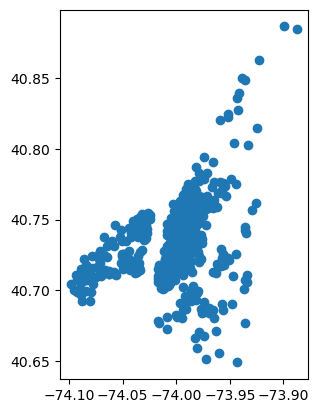

In [28]:
station_gdf.plot()

## Neighborhood Level Analysis
1. Route Level
2. read weather data
3. merge daily rides with the weather data
4. continue visualizations

### Route Level Analysis
1. create top_routes dataframe
2. Barplot top N routes | use station_id

In [29]:
route_summary = (
    citybike_df
    .dropna(
        subset=[
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ]
    )
    .groupby(
        [
            "start_station_id",
            "start_station_name",
            "end_station_id",
            "end_station_name",
            "start_lat",
            "start_lng",
            "end_lat",
            "end_lng"
        ],
        as_index=False
    )
    .agg(
        number_of_rides=("ride_id", "count")
    )
    .sort_values("number_of_rides", ascending=False)
)

route_summary["route"] = (
    route_summary["start_station_id"] +
    " → " +
    route_summary["end_station_id"]
)

route_summary.head()

,start_station_id,start_station_name,end_station_id,end_station_name,start_lat,start_lng,end_lat,end_lng,number_of_rides,route
83,HB101,Hoboken Terminal - Hudson St & Hudson Pl,JC105,Hoboken Ave at Monmouth St,40.735938,-74.030305,40.735208,-74.046964,4559,HB101 → JC105
5583,JC055,McGinley Square,JC109,Bergen Ave & Sip Ave,40.725340,-74.067622,40.731009,-74.064437,4306,JC055 → JC109
8709,JC115,Grove St PATH,JC013,Marin Light Rail,40.719410,-74.043090,40.714584,-74.042817,4131,JC115 → JC013
3937,JC013,Marin Light Rail,JC115,Grove St PATH,40.714584,-74.042817,40.719410,-74.043090,3831,JC013 → JC115
8723,JC115,Grove St PATH,JC052,Liberty Light Rail,40.719410,-74.043090,40.711242,-74.055701,3750,JC115 → JC052


In [30]:
top_routes = route_summary.head(20)

top_routes[
    [
        "route",
        "number_of_rides"
    ]
]

,route,number_of_rides
83,HB101 → JC105,4559
5583,JC055 → JC109,4306
8709,JC115 → JC013,4131
3937,JC013 → JC115,3831
8723,JC115 → JC052,3750
8445,JC109 → JC055,3609
5395,JC052 → JC115,3605
8154,JC105 → HB101,3257
4570,JC023 → JC115,3175
3788,JC009 → JC115,2998


In [31]:
top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 8

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

#### Top routes using Lines
1. changing the width
2. changing the color 

In [32]:
top_lines = route_summary.head(100).copy()

center_lat = station_gdf["lat"].mean()
center_lng = station_gdf["lng"].mean()

line_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

max_rides = top_lines["number_of_rides"].max()

threshold_value = top_lines["number_of_rides"].iloc[9] if len(top_lines) >= 10 else 0

for _, row in top_lines.iterrows():

    start_point = [
        row["start_lat"],
        row["start_lng"]
    ]

    end_point = [
        row["end_lat"],
        row["end_lng"]
    ]

    line_weight = 1 + (row["number_of_rides"] / max_rides) * 9 if row["number_of_rides"] >= threshold_value else 1 + (row["number_of_rides"] / max_rides) * 7
    
    line_color = "red" if row["number_of_rides"] >= threshold_value else "blue"

    folium.PolyLine(
        locations=[start_point, end_point],
        weight=line_weight,
        color=line_color,
        opacity=0.5,
        popup=f"""
        <b>{row['route']}</b><br>
        Number of Rides: {row['number_of_rides']}
        """
    ).add_to(line_map)

line_map

### Spatial Join
1. spatial_neigborhood geodaframe
2. analyze rides by neighborhood level
3. draw points for each station
4. Merge Neighborhood Metrics Back to Polygons

In [33]:
print("Station CRS:", station_gdf.crs)
print("Neighborhood CRS:", jersey_city.crs)

Station CRS: EPSG:4326
Neighborhood CRS: EPSG:4326


In [34]:
station_gdf = station_gdf.to_crs("EPSG:4326")
jersey_city = jersey_city.to_crs("EPSG:4326")

In [35]:
jersey_city.columns

Index(['cartodb_id', 'area_sq_ft', 'acres', 'area', 'neighborhood', 'color',
       'lon', 'lat', 'area_sq_km', 'estimated_neighborhood_population',
       'population_density_per_sq_km', 'nbhd_population', 'geometry'],
      dtype='str')

### Spatial Join: Assign Stations to Neighborhoods

In [36]:
station_neighborhood = gpd.sjoin(
    station_gdf,
    jersey_city,
    how="inner",
    predicate="within"
)

station_neighborhood.head()

,station_id,station_name,lat_left,lng,total_arrivals,total_departures,total_activity,net_departures,geometry,index_right,...,acres,area,neighborhood,color,lon,lat_right,area_sq_km,estimated_neighborhood_population,population_density_per_sq_km,nbhd_population
0,JC115,Grove St PATH,40.719410,-74.043090,47744.0,44984.0,92728.0,-2760.0,POINT (-74.04309 40.71941),49,...,9449.068,Downtown,Van Vorst Park,21.0,-74.047234,40.718943,38.23902,5739.716981,150.10105,5739.716981
2,JC009,Hamilton Park,40.727596,-74.044247,22347.0,22232.0,44579.0,-115.0,POINT (-74.04425 40.7276),10,...,9449.068,Downtown,Hamilton Park,28.0,-74.046672,40.727436,38.23902,5739.716981,150.10105,5739.716981
4,JC066,Newport PATH,40.727224,-74.033759,20698.0,20641.0,41339.0,-57.0,POINT (-74.03376 40.72722),8,...,9449.068,Downtown,Newport,22.0,-74.034927,40.729255,38.23902,5739.716981,150.10105,5739.716981
5,JC109,Bergen Ave & Sip Ave,40.731009,-74.064437,20357.0,20370.0,40727.0,13.0,POINT (-74.06444 40.73101),16,...,9449.068,Journal Square,Journal Square,NaN,-74.063466,40.733757,38.23902,5739.716981,150.10105,5739.716981
6,JC116,Exchange Pl,40.716366,-74.034344,20142.0,19982.0,40124.0,-160.0,POINT (-74.03434 40.71637),48,...,9449.068,Downtown,Exchange Place,23.0,-74.033539,40.716458,38.23902,5739.716981,150.10105,5739.716981


In [37]:
print("All stations:", len(station_gdf))
print("Stations inside Jersey City neighborhoods:", len(station_neighborhood))

All stations: 488
Stations inside Jersey City neighborhoods: 79


### Neighborhood-Level Summary

In [38]:
neighborhood_activity = (
    station_neighborhood
    .groupby('neighborhood', as_index=False)
    .agg(
        number_of_stations=("station_id", "nunique"),
        total_departures=("total_departures", "sum"),
        total_arrivals=("total_arrivals", "sum"),
        total_activity=("total_activity", "sum"),
        net_departures=("net_departures", "sum")
    )
)

neighborhood_activity["avg_activity_per_station"] = (
    neighborhood_activity["total_activity"] /
    neighborhood_activity["number_of_stations"]
)

neighborhood_activity = neighborhood_activity.sort_values(
    "total_activity",
    ascending=False
)

neighborhood_activity.head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
25,Van Vorst Park,6,96144.0,98853.0,194997.0,-2709.0,32499.500000
17,Palus Hook,6,59496.0,59160.0,118656.0,336.0,19776.000000
14,Newport,2,39350.0,39402.0,78752.0,-52.0,39376.000000
10,Journal Square,3,32970.0,32560.0,65530.0,410.0,21843.333333
4,Hamilton Park,2,31729.0,31922.0,63651.0,-193.0,31825.500000


### Points for each Station

#### Center Point of the map 

In [39]:
center_lat = station_gdf.geometry.y.mean()
center_lng = station_gdf.geometry.x.mean()

center_lat, center_lng

(np.float64(40.7340122586309), np.float64(-74.00137516113631))

In [40]:
station_point_map = folium.Map(
    location=[center_lat, center_lng],
    zoom_start=12
)

for _, row in station_gdf.iterrows():

    folium.CircleMarker(
        location=[
            row.geometry.y,
            row.geometry.x
        ],
        radius=5,
        popup=f"""
        <b>{row['station_name']}</b><br>
        Station ID: {row['station_id']}<br>
        Departures: {row['total_departures']:.0f}<br>
        Arrivals: {row['total_arrivals']:.0f}<br>
        Total Activity: {row['total_activity']:.0f}<br>
        Net Departures: {row['net_departures']:.0f}
        """,
        tooltip=row["station_name"],
        fill=True,
        fill_opacity=0.6,
        opacity=0.8
    ).add_to(station_point_map)

station_point_map

### Merge Neighborhood Metrics Back to Polygons

In [41]:
neighborhood_choropleth_gdf = jersey_city.merge(
    neighborhood_activity,
    on='neighborhood',
    how="left"
)

neighborhood_choropleth_gdf.head()

,cartodb_id,area_sq_ft,acres,area,neighborhood,color,lon,lat,area_sq_km,estimated_neighborhood_population,population_density_per_sq_km,nbhd_population,geometry,number_of_stations,total_departures,total_arrivals,total_activity,net_departures,avg_activity_per_station
0,38,411601381.8,9449.068,Greenville,Port Liberte,NaN,-74.074540,40.694202,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.06862 40.70098, -74.06808 40.696...",1.0,12.0,9.0,21.0,3.0,21.0000
1,52,411601381.8,9449.068,Bergen-Lafayette,LSP Industrial,NaN,-74.062358,40.699189,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.06808 40.69684, -74.06862 40.700...",NaN,NaN,NaN,NaN,NaN,NaN
2,29,411601381.8,9449.068,West Side,Hackensack,NaN,-74.085147,40.735520,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.07601 40.73822, -74.07781 40.737...",NaN,NaN,NaN,NaN,NaN,NaN
3,35,411601381.8,9449.068,Bergen-Lafayette,Lafayette,12.0,-74.061279,40.712676,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.056 40.71735, -74.056 40.71692, ...",6.0,30845.0,30730.0,61575.0,115.0,10262.5000
4,51,411601381.8,9449.068,Greenville,Jackson Hill,15.0,-74.085503,40.700791,38.23902,5739.716981,150.10105,5739.716981,"POLYGON ((-74.07561 40.70233, -74.0758 40.7020...",16.0,6142.0,6045.0,12187.0,97.0,761.6875


### Coropleth Maps

In [42]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.0000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.0000
2,Hackensack,0.0,0.0,0.0,0.0,0.0000
3,Lafayette,6.0,30845.0,30730.0,61575.0,10262.5000
4,Jackson Hill,16.0,6142.0,6045.0,12187.0,761.6875


In [43]:
activity_columns = [
    "number_of_stations",
    "total_departures",
    "total_arrivals",
    "total_activity",
    "net_departures",
    "avg_activity_per_station"
]

neighborhood_choropleth_gdf[activity_columns] = (
    neighborhood_choropleth_gdf[activity_columns]
    .fillna(0)
)

neighborhood_choropleth_gdf[
    [
        'neighborhood',
        "number_of_stations",
        "total_departures",
        "total_arrivals",
        "total_activity",
        "avg_activity_per_station"
    ]
].head()

,neighborhood,number_of_stations,total_departures,total_arrivals,total_activity,avg_activity_per_station
0,Port Liberte,1.0,12.0,9.0,21.0,21.0000
1,LSP Industrial,0.0,0.0,0.0,0.0,0.0000
2,Hackensack,0.0,0.0,0.0,0.0,0.0000
3,Lafayette,6.0,30845.0,30730.0,61575.0,10262.5000
4,Jackson Hill,16.0,6142.0,6045.0,12187.0,761.6875


#### Helper Function for Folium Choropleth

In [44]:

def create_neighborhood_choropleth(
    gdf,
    metric,
    legend_name,
    neighborhood_col="neighborhood"
):
    choropleth_map = folium.Map(
        location=[center_lat, center_lng],
        zoom_start=12
    )

    folium.Choropleth(
        geo_data=gdf,
        data=gdf,
        columns=[neighborhood_col, metric],
        key_on=f"feature.properties.{neighborhood_col}",
        fill_opacity=0.7,
        line_opacity=0.4,
        legend_name=legend_name,
        nan_fill_opacity=0.1
    ).add_to(choropleth_map)

    folium.GeoJson(
        gdf,
        name="Neighborhood Boundaries",
        tooltip=folium.GeoJsonTooltip(
            fields=[
                neighborhood_col,
                metric
            ],
            aliases=[
                "Neighborhood:",
                f"{legend_name}:"
            ],
            localize=True
        ),
        style_function=lambda feature: {
            "fillOpacity": 0,
            "color": "black",
            "weight": 1
        }
    ).add_to(choropleth_map)

    folium.LayerControl().add_to(choropleth_map)

    return choropleth_map

#### Choropleth: Total Activity by Neighborhood

In [45]:
total_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_activity",
    legend_name="Total City Bike Activity",
    neighborhood_col="neighborhood"
)

total_activity_map

In [46]:
#### Choropleth by Number of Stations

In [47]:
station_count_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="number_of_stations",
    legend_name="Number of Citi Bike Stations",
    neighborhood_col="neighborhood"
)

station_count_map

#### Choropleth by Average Activity per Station

In [48]:
avg_activity_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="avg_activity_per_station",
    legend_name="Average Activity per Station",
    neighborhood_col="neighborhood"
)

avg_activity_map

#### Choropleth by Total Departures

In [49]:
departures_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_departures",
    legend_name="Total Departures",
    neighborhood_col="neighborhood"
)

departures_map

#### Choropleth by Total Arrivals

In [50]:
arrivals_map = create_neighborhood_choropleth(
    gdf=neighborhood_choropleth_gdf,
    metric="total_arrivals",
    legend_name="Total Arrivals",
    neighborhood_col="neighborhood"
)

arrivals_map